In [4]:
import os
import numpy as np
import pandas as pd

# Crear directorio datasets si no existe
if not os.path.exists('datasets'):
    os.makedirs('datasets')

###############################
# Generar segments.csv
###############################
# Definimos tres centroides en 3D
centers = np.array([
    [20, 80,  8],
    [50, 20,  5],
    [20, 30, 10]
])

# Número de puntos por clúster
points_per_cluster = 100

all_points = []
for center in centers:
    # Creamos un cluster de 'points_per_cluster' puntos alrededor de cada centro
    cluster_data = center + np.random.randn(points_per_cluster, 3) * 5
    all_points.append(cluster_data)

# Unimos los puntos en un solo array
X = np.vstack(all_points)

# Creamos un DataFrame con nombres de columnas
df_segments = pd.DataFrame(X, columns=["feature1", "feature2", "feature3"])
segments_path = 'segments.csv'
df_segments.to_csv(segments_path, index=False)
print(f'Archivo {segments_path} generado con {len(df_segments)} filas.')

###############################
# Generar sales.csv
###############################
# Supongamos 500 puntos normales y 10 anómalos
n_normal = 500
n_outliers = 10

# Datos normales de ventas y ganancias
np.random.seed(42)
sales_normal = np.random.normal(loc=50, scale=10, size=n_normal)   # Ej. media 50, std 10
profit_normal = np.random.normal(loc=10, scale=2, size=n_normal)   # Ej. media 10, std 2

# Datos anómalos
sales_outliers = np.random.uniform(low=150, high=300, size=n_outliers)  # Ventas muy altas
profit_outliers = np.random.uniform(low=-10, high=100, size=n_outliers) # Ganancias fuera de rango

# Unimos datos
sales_all = np.concatenate([sales_normal, sales_outliers])
profit_all = np.concatenate([profit_normal, profit_outliers])

df_sales = pd.DataFrame({
    'Sales': sales_all,
    'Profit': profit_all
})

sales_path = 'sales.csv'
df_sales.to_csv(sales_path, index=False)
print(f'Archivo {sales_path} generado con {len(df_sales)} filas.')


Archivo segments.csv generado con 300 filas.
Archivo sales.csv generado con 510 filas.


# Momento 1: Creación de Clústeres con KMeans

En este ejercicio:
- Se lee un conjunto de datos desde `segments.csv`.
- Se define un modelo de KMeans con 3 clústeres.
- Se ajusta el modelo con centroides aleatorios y luego con centroides iniciales definidos.
- Finalmente, se visualiza la agrupación en un diagrama de dispersión.

C:\Users\ljpca\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\ljpca\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Centroides de clúster (aleatorios):
[[21.30867091 29.97998369  9.91128119]
 [20.88670314 79.97743434  8.47935057]
 [51.11004709 19.7792768   4.61018641]]

Centroides de clúster (con centroides iniciales):
[[20.88670314 79.97743434  8.47935057]
 [50.95533351 19.78010829  4.70269712]
 [21.16537073 30.08115928  9.87178142]]


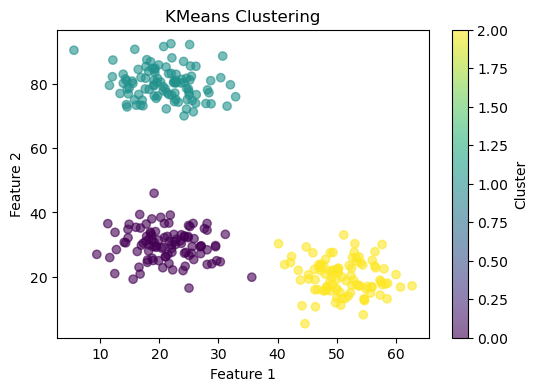

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Cargar los datos
data = pd.read_csv('segments.csv')

# 2. Definir centroides iniciales (opcional)
centers = np.array([[20, 80, 8], [50, 20, 5], [20, 30, 10]])

# 3. Entrenar el modelo con centroides aleatorios
model_random = KMeans(n_clusters=3, random_state=12345)
model_random.fit(data)
print('Centroides de clúster (aleatorios):')
print(model_random.cluster_centers_)

# 4. Entrenar el modelo con centroides iniciales definidos
model_init = KMeans(n_clusters=3, init=centers, n_init=1, random_state=12345)
model_init.fit(data)
print('\nCentroides de clúster (con centroides iniciales):')
print(model_init.cluster_centers_)

# 5. Visualizar la agrupación
#   - Tomamos solo 2 columnas para graficar (por ejemplo, las dos primeras)
#   - En caso de tener más de 2, el gráfico será una aproximación.

labels = model_random.labels_
plt.figure(figsize=(6, 4))
plt.scatter(data.iloc[:, 0], data.iloc[:, 1], c=labels, cmap='viridis', alpha=0.6)
plt.title('KMeans Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster')
plt.show()

# Momento 2: Detección de Anomalías

En este ejercicio:
- Se lee un conjunto de datos desde `sales.csv`.
- Se usan dos métodos de detección de anomalías:
  1. **KNN** (K-Nearest Neighbors) de la librería PyOD.
  2. **IsolationForest** de `sklearn.ensemble`.
- Se comparan cuántos valores anómalos detecta cada uno y cuántos coinciden en ambos métodos.

In [10]:
import pandas as pd
from pyod.models.knn import KNN
from sklearn.ensemble import IsolationForest

# 1. Cargar los datos
df = pd.read_csv('sales.csv')
data = df[['Sales', 'Profit']]  # Seleccionamos las columnas relevantes

# 2. Detección de anomalías con KNN (PyOD)
model_knn = KNN()
estimation_knn = model_knn.fit_predict(data) == 1  # True si es anomalía
outliers_knn = estimation_knn.sum()
print('Número de anomalías (KNN):', outliers_knn)

# 3. Detección de anomalías con IsolationForest
model_iforest = IsolationForest(n_estimators=100, random_state=42)
estimation_iforest = model_iforest.fit_predict(data) == -1  # True si es anomalía
outliers_iforest = estimation_iforest.sum()
print('Número de anomalías (bosque de aislamiento):', outliers_iforest)

# 4. Comparar coincidencias
coincidentes = (estimation_knn & estimation_iforest).sum()
print('Anomalías coincidentes en ambos métodos:', coincidentes)

Número de anomalías (KNN): 51
Número de anomalías (bosque de aislamiento): 43
Anomalías coincidentes en ambos métodos: 38


C:\Users\ljpca\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function fit_predict is deprecated
  warnings.warn(msg, category=FutureWarning)
